# This in an attempt at GAN, Generative adversarial network using TENSORFLOW    

In [1]:
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers
import os
import glob
import random
import pandas as pd

import re

In [2]:
# =========================
# USER CONFIG
# =========================

FILTER_MODE = "keyword"   # "all", "keyword", "country"

KEYWORDS = {
    "hotdog": r"\bhot\s*dog\b",
    "burger": r"burger",
    "sandwich": r"sandwich"
}

SELECTED_KEY = "hotdog"   # which keyword to use

SELECTED_COUNTRY = "GER" 

USE_AUGMENTATION = True   # ✅ toggle do you want to make 1 picture into 8 via flippin and mirrorin'
MAX_IMAGES = 2000

df = pd.read_csv("../data/grand_scraper_folder/unique_scrandle_cases_FULL.csv")


In [3]:
df = pd.read_csv("../data/grand_scraper_folder/unique_scrandle_cases_FULL.csv")

# convert country to list
df["country_list"] = df["country"].fillna("").apply(lambda x: x.split(" | "))

In [4]:
if FILTER_MODE == "keyword":
    pattern = KEYWORDS[SELECTED_KEY]

    mask = (
        df["title"].str.contains(pattern, case=False, na=False, regex=True) |
        df["subtitle"].str.contains(pattern, case=False, na=False, regex=True)
    )
    df = df[mask]

elif FILTER_MODE == "country":
    df = df[df["country_list"].apply(lambda x: SELECTED_COUNTRY in x)]

# "all" → do nothing

print("Filtered unique cases:", len(df))

Filtered unique cases: 374


In [5]:
base_folder = "../data/scrandle_padded_low_res_data"

def get_image_path(occurrence):
    date, rest = occurrence.split(":")
    match_id, side = rest.split("_")
    return os.path.join(base_folder, date, f"{match_id}_{side}.webp")

def safe_get_image_path(occurrence):
    path = get_image_path(occurrence)
    return path if os.path.exists(path) else None

image_paths = []

for _, row in df.iterrows():
    first_occ = row["occurrences"].split(" | ")[0]
    path = safe_get_image_path(first_occ)

    if path:
        image_paths.append(path)



        
# shuffle + limit
import random
random.shuffle(image_paths)

if MAX_IMAGES:
    image_paths = image_paths[:MAX_IMAGES]

print("Images used:", len(image_paths))


Images used: 374


In [6]:
IMG_SIZE = 64

def preprocess(path):
    img = tf.io.read_file(path)
    img = tf.io.decode_image(img, channels=3, expand_animations=False)
    img.set_shape([None, None, 3])

    # crop padding
    h = tf.shape(img)[0]
    w = tf.shape(img)[1]

    top = tf.cast(0.2 * tf.cast(h, tf.float32), tf.int32)
    right = tf.cast(0.8 * tf.cast(w, tf.float32), tf.int32)

    img = img[top:, :right, :]

    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])

    img = tf.cast(img, tf.float32)
    img = (img / 127.5) - 1

    img = tf.clip_by_value(img, -1.0, 1.0)

    return img

In [7]:
def augment(img):
    imgs = []

    # rotations (0, 90, 180, 270)
    for k in range(4):
        r = tf.image.rot90(img, k)
        imgs.append(r)                          # original rotation
        imgs.append(tf.image.flip_left_right(r))  # mirrored

    imgs = tf.stack(imgs)
    imgs.set_shape((8, IMG_SIZE, IMG_SIZE, 3))  # ✅ stabilizes TF graph

    return imgs

In [8]:
dataset = tf.data.Dataset.from_tensor_slices(image_paths)
dataset = dataset.map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)

# ✅ AUGMENTATION TOGGLE
if USE_AUGMENTATION:
    dataset = dataset.map(augment, num_parallel_calls=tf.data.AUTOTUNE)
    dataset = dataset.unbatch()  # turns 1 image -> 8 images

dataset = dataset.shuffle(len(image_paths))
dataset = dataset.batch(64)
dataset = dataset.prefetch(tf.data.AUTOTUNE)
dataset = dataset.repeat()

In [9]:
def build_generator():
    model = tf.keras.Sequential()

    model.add(layers.Input(shape=(100,)))

    model.add(layers.Dense(8 * 8 * 512, use_bias=False))  # ✅ larger
    model.add(layers.BatchNormalization())
    model.add(layers.ReLU())

    model.add(layers.Reshape((8, 8, 512)))  # ✅ FIXED

    model.add(layers.Conv2DTranspose(256, 4, strides=2, padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.ReLU())

    model.add(layers.Conv2DTranspose(128, 4, strides=2, padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.ReLU())

    model.add(layers.Conv2DTranspose(3, 4, strides=2, padding='same', activation='tanh'))

    return model


In [10]:
def build_discriminator():
    model = tf.keras.Sequential()

    model.add(layers.Input(shape=(64, 64, 3)))

    model.add(layers.Conv2D(64, 4, strides=2, padding='same'))   # 64 → 32
    model.add(layers.LeakyReLU(0.2))
    model.add(layers.Dropout(0.3))

    model.add(layers.Conv2D(128, 4, strides=2, padding='same'))  # 32 → 16
    model.add(layers.LeakyReLU(0.2))
    model.add(layers.Dropout(0.3))

    model.add(layers.Conv2D(256, 4, strides=2, padding='same'))  # ✅ NEW → 16 → 8
    model.add(layers.LeakyReLU(0.2))
    model.add(layers.Dropout(0.3))

    model.add(layers.Flatten())
    model.add(layers.Dense(1))

    return model


In [11]:
cross_entropy = tf.keras.losses.BinaryCrossentropy(from_logits=True)

def d_loss(real, fake):
    return cross_entropy(tf.ones_like(real) * 0.9, real) + \
           cross_entropy(tf.zeros_like(fake), fake)

def g_loss(fake):
    return cross_entropy(tf.ones_like(fake), fake)



In [12]:
generator = build_generator()
discriminator = build_discriminator()

g_optimizer = tf.keras.optimizers.Adam(1e-4)
d_optimizer = tf.keras.optimizers.Adam(1e-4)


In [13]:
@tf.function
def train_step(images):
    batch_size = tf.shape(images)[0]
    noise = tf.random.normal([batch_size, 100])

    with tf.GradientTape() as tape_g, tf.GradientTape() as tape_d:
        generated = generator(noise, training=True)

        real_out = discriminator(images, training=True)
        fake_out = discriminator(generated, training=True)

        loss_g = g_loss(fake_out)
        loss_d = d_loss(real_out, fake_out)

    grads_g = tape_g.gradient(loss_g, generator.trainable_variables)
    grads_d = tape_d.gradient(loss_d, discriminator.trainable_variables)

    g_optimizer.apply_gradients(zip(grads_g, generator.trainable_variables))
    d_optimizer.apply_gradients(zip(grads_d, discriminator.trainable_variables))


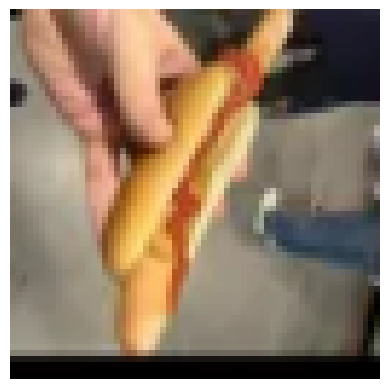

In [14]:
for x in dataset.take(1):
    img = (x[0] + 1) / 2
    plt.imshow(img)
    plt.axis("off")



Epoch 0


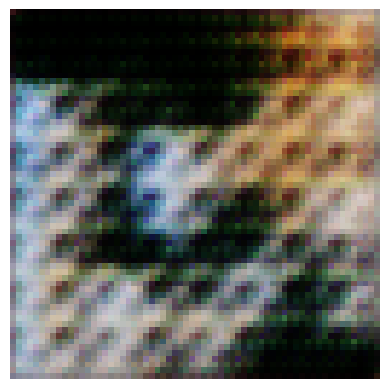


Epoch 1


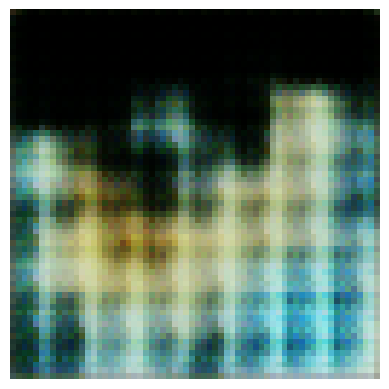


Epoch 2


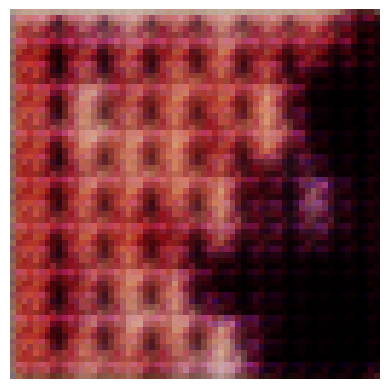


Epoch 3


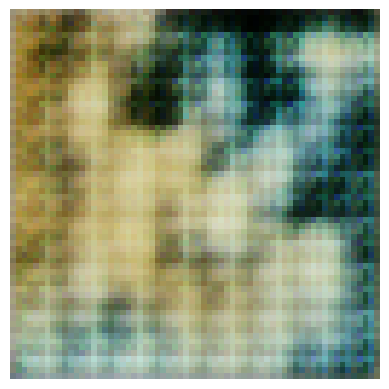


Epoch 4


KeyboardInterrupt: 

In [20]:
steps_per_epoch = 200
EPOCHS = 15
for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch}")

    for image_batch in dataset.take(steps_per_epoch):
        train_step(image_batch)

    # ✅ generate sample after each epoch
    noise = tf.random.normal([1, 100])
    generated = generator(noise, training=False)

    img = (generated[0] + 1) / 2
    plt.imshow(img)
    plt.axis("off")
    plt.show()
        



(np.float64(-0.5), np.float64(63.5), np.float64(63.5), np.float64(-0.5))

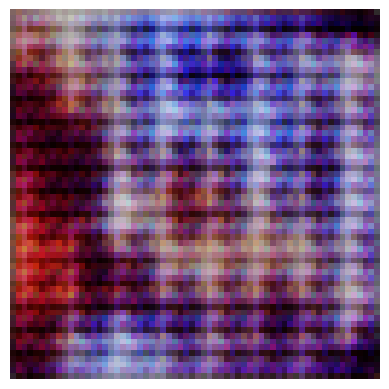

In [19]:
noise = tf.random.normal([1, 100])
generated = generator(noise, training=False)

img = (generated[0] + 1) / 2  # back to [0,1]

plt.imshow(img)
plt.axis("off")
